In [3]:
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt
from numpy.linalg import norm
from mpl_toolkits.mplot3d import Axes3D 

Total power (energy/time) =  111090.27840917217
Trajectory distance (control vs undisturbed): 5.1079442530450905


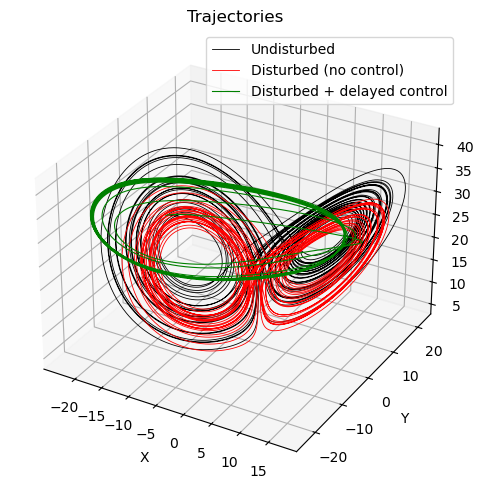

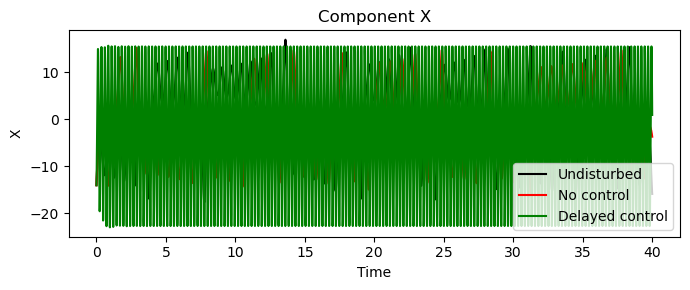

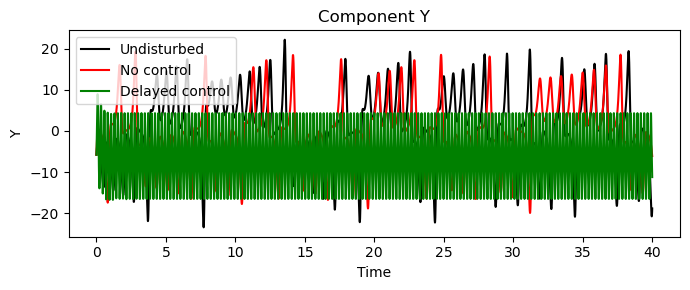

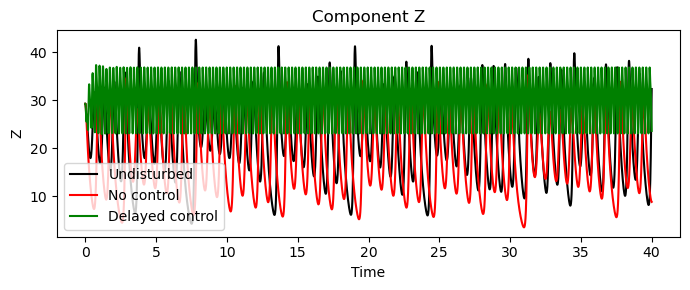

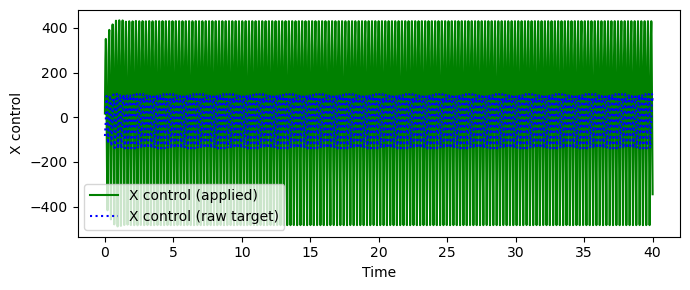

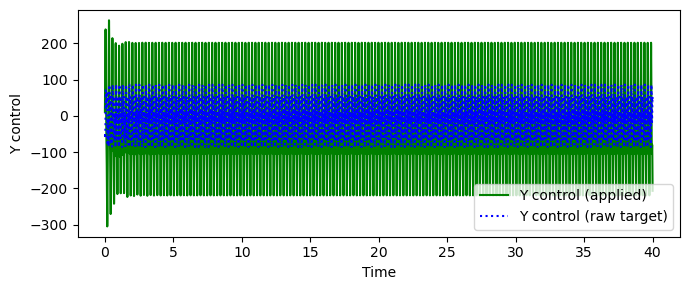

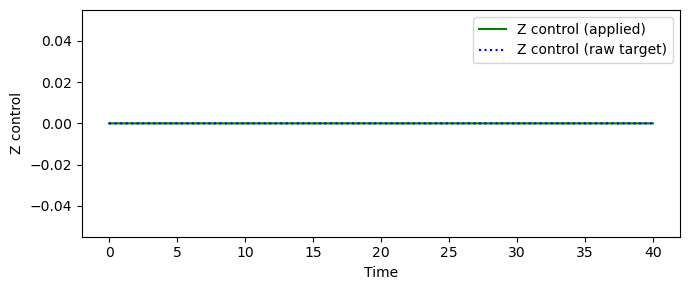

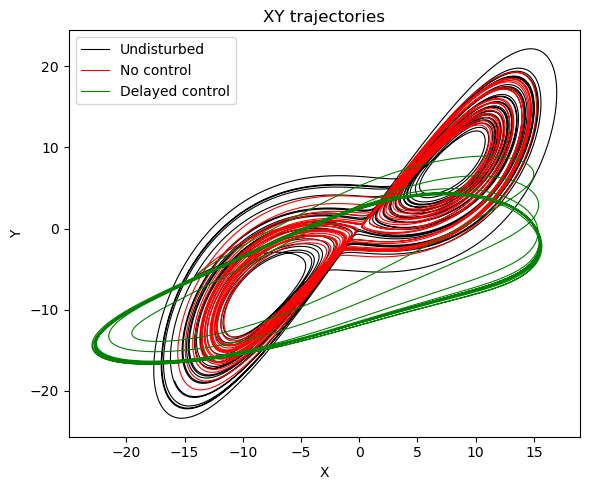

In [18]:
# Shared systems, integrators, and reservoir utilities (aligned with feedbackcontrol)
from dataclasses import dataclass
from typing import Callable, Dict, Tuple, Optional
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt

# 1) Dynamical systems
def sprott_linz_deriv(x: np.ndarray, params: Dict[str, float]) -> np.ndarray:
    a = params.get('a', 0.42)
    x_, y_, z_ = x
    return np.array([y_ + z_, -x_ + a * y_, x_**2 - z_])


def lorenz_deriv(x: np.ndarray, params: Dict[str, float]) -> np.ndarray:
    sigma = params.get('sigma', 10.0)
    rho   = params.get('rho', 28.0)
    beta  = params.get('beta', 8.0/3.0)
    x_, y_, z_ = x
    return np.array([sigma * (y_ - x_), x_ * (rho - z_) - y_, x_ * y_ - beta * z_])


def get_system(system_name: str) -> Tuple[Callable[[np.ndarray, Dict[str,float]], np.ndarray], Dict[str, float]]:
    name = system_name.lower()
    if name in ['sprott-linz', 'sprott_linz', 'sprott']:
        return sprott_linz_deriv, {'a': 0.42}
    if name in ['lorenz', 'lorenz63']:
        return lorenz_deriv, {'sigma': 10.0, 'rho': 28.0, 'beta': 8.0/3.0}
    raise ValueError(f"Unknown system '{system_name}'. Use 'sprott-linz' or 'lorenz'.")

# 2) Integrators
def euler_step(
    f: Callable[[np.ndarray, Dict[str,float]], np.ndarray],
    x: np.ndarray,
    dt: float,
    params: Dict[str,float]
) -> np.ndarray:
    return x + dt * f(x, params)


def rk4_step(
    f: Callable[[np.ndarray, Dict[str,float]], np.ndarray],
    x: np.ndarray,
    dt: float,
    params: Dict[str,float]
) -> np.ndarray:
    k1 = f(x, params)
    k2 = f(x + 0.5 * dt * k1, params)
    k3 = f(x + 0.5 * dt * k2, params)
    k4 = f(x + dt * k3, params)
    return x + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)


def get_stepper(method: str):
    method = method.lower()
    if method == 'euler':
        return euler_step
    if method in ['rk4', 'runge-kutta', 'rk']:
        return rk4_step
    raise ValueError("Integrator must be 'euler' or 'rk4'.")

# 3) Reservoir and training (using pre-defined forcing functions)
@dataclass
class Reservoir:
    A: sp.csr_matrix
    Win: np.ndarray
    bias: float


def build_reservoir(
    n: int,
    m: int,
    spectral_radius: float = 1.2,
    density: float = 6.0,
    input_scale: float = 0.1,
    bias: float = 1.0,
    seed: Optional[int] = None,
) -> Reservoir:
    rng = np.random.default_rng(seed)
    A_rand = sp.random(n, n, density=density/n, format='csr', random_state=seed)
    A_data = A_rand.toarray()
    A_data = A_data - 0.5 * np.sign(A_data)
    A_temp = sp.csr_matrix(A_data)
    eigvals = sp.linalg.eigs(A_temp, k=1, which='LR', return_eigenvectors=False)
    A_scaled = A_temp * (spectral_radius / np.abs(eigvals[0]))
    Win = input_scale * (2.0 * rng.random((n, m)) - 1.0)
    return Reservoir(A=A_scaled.tocsr(), Win=Win, bias=bias)


def train_reservoir_with_forcing(
    deriv: Callable[[np.ndarray, Dict[str,float]], np.ndarray],
    params: Dict[str,float],
    reservoir: Reservoir,
    x0: np.ndarray,
    T: float,
    dt: float,
    lam: float = 1e-4,
    washout: int = 1000,
    integrator: str = 'rk4',
    seed: Optional[int] = None,
) -> Dict[str, np.ndarray]:
    """
    Train Wout to map reservoir state R -> prescribed forcing F(t).
    You can edit the internal `forcing` function to change the predefined signals.
    """
    stepper = get_stepper(integrator)
    n_steps = int(T / dt)
    m = len(x0)
    n = reservoir.A.shape[0]
    rng = np.random.default_rng(seed)

    # Storage
    R = np.zeros((n, n_steps))
    F = np.zeros((m, n_steps))

    # Initial states
    r = 2.0 * rng.random(n) - 1.0
    x = x0.copy()

    # Predefined forcing (edit here if needed)
    def forcing(t_idx: int, dt_local: float, x_state: np.ndarray) -> np.ndarray:
        fx = 100.0 * np.cos(0.05 * dt_local * t_idx)
        fy = 100.0 * np.sin(0.05 * dt_local * t_idx)
        fz = 0.0
        return np.array([fx, fy, fz])

    for t in range(n_steps):
        u_state = x.copy()
        R[:, t] = r
        f_vec = forcing(t, dt, x)
        F[:, t] = f_vec

        # Advance the physical system with additive forcing
        x = stepper(lambda xx, pp: deriv(xx, params) + f_vec, x, dt, None)

        # Advance reservoir with current state as input
        r = np.tanh(reservoir.A.dot(r) + reservoir.Win.dot(u_state) + reservoir.bias)

    if washout >= n_steps:
        raise ValueError("Washout >= total steps; reduce washout or increase T.")

    R_eff = R[:, washout:]
    F_eff = F[:, washout:]
    Id = np.eye(n)
    Wout = F_eff.dot(R_eff.T).dot(np.linalg.inv(R_eff.dot(R_eff.T) + lam * Id))
    return {'Wout': Wout, 'x_last': x, 'r_last': r}

# 4) Disturbance and metrics

def apply_value_disturbance(params: Dict[str,float], disturb_value: float, key: str) -> Dict[str,float]:
    newp = dict(params)
    newp[key] = params[key] + disturb_value
    return newp


def trajectory_shortest_distance(true: np.ndarray, pred: np.ndarray, n_samples: int = 100, seed: Optional[int] = None) -> float:
    T_pred = pred.shape[1]
    if T_pred == 0:
        return float('nan')
    n_eff = min(n_samples, T_pred)
    rng = np.random.default_rng(seed)
    idxs = rng.choice(T_pred, size=n_eff, replace=False)
    total = 0.0
    for idx in idxs:
        p = pred[:, idx][:, None]
        dists = np.linalg.norm(true - p, axis=0)
        total += float(dists.min())
    return total / n_eff

# 5) Delayed control simulation (similar structure to feedbackcontrol)

def simulate_delayed_control(
    system_name: str = 'lorenz',
    system_params: Optional[Dict[str,float]] = None,
    disturb_key: Optional[str] = None,
    disturb_value: float = 0.0,
    training_time: float = 200.0,
    forecast_time: float = 40.0,
    dt: float = 0.002,
    reservoir_size: int = 1000,
    spectral_radius: float = 1.2,
    density: float = 6.0,
    input_scale: float = 0.1,
    bias: float = 1.0,
    lam: float = 1e-4,
    washout: int = 0,
    integrator: str = 'euler',
    seed: int = 121,
    control_gain: float = 1000.0,  # alpha
    tau: float = 10.0,
) -> Dict[str, np.ndarray]:
    deriv, default_params = get_system(system_name)
    if system_params:
        default_params.update(system_params)
    params_nominal = default_params

    # Disturbance target param
    if disturb_key is None:
        disturb_key = next(iter(params_nominal.keys()))
    params_disturbed = apply_value_disturbance(params_nominal, disturb_value, disturb_key)

    # Build and train reservoir using predefined forcing
    rng = np.random.default_rng(seed)
    x0 = rng.random(3) - 0.5
    reservoir = build_reservoir(
        n=reservoir_size, m=3,
        spectral_radius=spectral_radius, density=density,
        input_scale=input_scale, bias=bias, seed=seed,
    )
    tr = train_reservoir_with_forcing(
        deriv, params_nominal, reservoir, x0,
        T=training_time, dt=dt, lam=lam, washout=washout,
        integrator=integrator, seed=seed,
    )

    # Simulation setup
    n_steps = int(forecast_time / dt)
    times = np.linspace(0.0, forecast_time, n_steps)

    undist = np.zeros((3, n_steps))
    noctrl = np.zeros((3, n_steps))
    ctrl   = np.zeros((3, n_steps))
    targets_raw = np.zeros((3, n_steps))    # reservoir raw control suggestion
    control_inputs = np.zeros((3, n_steps)) # filtered + scaled control actually applied

    x_u = tr['x_last'].copy()
    x_n = tr['x_last'].copy()
    x_c = tr['x_last'].copy()
    r   = tr['r_last'].copy()
    v   = np.zeros(3)  # filtered control state

    stepper = get_stepper(integrator)

    # Bind parameterized derivatives
    f_nominal   = lambda xx, pp: deriv(xx, params_nominal)
    f_disturbed = lambda xx, pp: deriv(xx, params_disturbed)

    for t in range(n_steps):
        # Log
        undist[:, t] = x_u
        noctrl[:, t] = x_n
        ctrl[:, t]   = x_c

        # Advance undisturbed and disturbed-no-control
        x_u = stepper(f_nominal, x_u, dt, None)
        x_n = stepper(f_disturbed, x_n, dt, None)

        # Reservoir-driven delayed control
        r = np.tanh(reservoir.A.dot(r) + reservoir.Win.dot(x_c) + reservoir.bias)
        u_raw = tr['Wout'].dot(r)     # raw control proposal from reservoir
        v = v + (dt / tau) * (u_raw - v)  # first-order lag filter
        u = -control_gain * v              # applied control (sign chosen to counteract)

        targets_raw[:, t] = u_raw
        control_inputs[:, t] = u

        # Advance controlled disturbed system
        x_c = stepper(lambda xx, pp: f_disturbed(xx, None) + u, x_c, dt, None)

    return {
        'times': times,
        'undisturbed': undist,
        'disturbed_no_control': noctrl,
        'disturbed_control': ctrl,
        'targets': targets_raw,
        'control_inputs': control_inputs,
        'params_nominal': params_nominal,
        'params_disturbed': params_disturbed,
        'disturbance_key': np.array([disturb_key], dtype=object),
        'disturbance_value': np.array([disturb_value]),
        'control_gain': np.array([control_gain]),
        'tau': np.array([tau]),
    }

# 6) Evaluation utilities (similar to feedbackcontrol)

def evaluate_control(results: Dict[str, np.ndarray], dt: float, n_samples: int = 200, seed: Optional[int] = None) -> Dict[str, float]:
    und = results['undisturbed']
    ctr = results['disturbed_control']
    dist = trajectory_shortest_distance(und, ctr, n_samples=n_samples, seed=seed)

    times = results['times']
    Ttest = float(times[-1] - times[0]) if times.size > 0 else 0.0
    u = results.get('control_inputs')
    if u is None or Ttest <= 0.0:
        total_power = float('nan')
    else:
        total_power = np.sum(dt * np.sum(u**2, axis=0)) / Ttest

    print("Total power (energy/time) = ", total_power)
    return {'control_distance': float(dist), 'total_power': float(total_power)}

# 7) Plotting utilities (similar to feedbackcontrol)

def plot_delayed_control_results(results: Dict[str, np.ndarray], from_time: float = 0.0, to_time: Optional[float] = None):
    times = results['times']
    und  = results['undisturbed']
    noc  = results['disturbed_no_control']
    ctr  = results['disturbed_control']

    if to_time is None:
        to_time = float(times[-1])
    mask = (times >= from_time) & (times <= to_time)
    t = times[mask]
    und_sel, noc_sel, ctr_sel = und[:, mask], noc[:, mask], ctr[:, mask]

    # 3D trajectories
    fig = plt.figure(figsize=(6, 5))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot(und_sel[0], und_sel[1], und_sel[2], 'k', lw=0.6, label='Undisturbed')
    ax.plot(noc_sel[0], noc_sel[1], noc_sel[2], 'r', lw=0.6, label='Disturbed (no control)')
    ax.plot(ctr_sel[0], ctr_sel[1], ctr_sel[2], 'g', lw=0.8, label='Disturbed + delayed control')
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    ax.set_title('Trajectories')
    ax.legend(); plt.tight_layout()

    comps = ['X','Y','Z']
    for i in range(3):
        plt.figure(figsize=(7, 3))
        plt.plot(t, und_sel[i], 'k', label='Undisturbed')
        plt.plot(t, noc_sel[i], 'r', label='No control')
        plt.plot(t, ctr_sel[i], 'g', label='Delayed control')
        plt.xlabel('Time'); plt.ylabel(comps[i])
        plt.title(f'Component {comps[i]}')
        plt.legend(); plt.tight_layout()


def plot_control_inputs(results: Dict[str, np.ndarray], from_time: float = 0.0, to_time: Optional[float] = None, show_raw: bool = True):
    times = results['times']
    if to_time is None:
        to_time = float(times[-1])
    mask = (times >= from_time) & (times <= to_time)
    t = times[mask]

    u = results['control_inputs'][:, mask]
    if show_raw and 'targets' in results:
        ur = results['targets'][:, mask]
    else:
        ur = None

    comps = ['X','Y','Z']
    for i in range(3):
        plt.figure(figsize=(7, 3))
        plt.plot(t, u[i], 'g', label=f'{comps[i]} control (applied)')
        if ur is not None:
            plt.plot(t, ur[i], 'b:', label=f'{comps[i]} control (raw target)')
        plt.xlabel('Time'); plt.ylabel(f'{comps[i]} control')
        plt.legend(); plt.tight_layout()


def plot_xy_2d(results: Dict[str, np.ndarray], from_time: float = 0.0, to_time: Optional[float] = None):
    times = results['times']
    if to_time is None:
        to_time = float(times[-1]) if times.size else 0.0
    mask = (times >= from_time) & (times <= to_time)

    und = results.get('undisturbed')
    noc = results.get('disturbed_no_control')
    ctr = results.get('disturbed_control')

    plt.figure(figsize=(6, 5))
    if und is not None:
        plt.plot(und[0, mask], und[1, mask], 'k', lw=0.8, label='Undisturbed')
    if noc is not None:
        plt.plot(noc[0, mask], noc[1, mask], 'r', lw=0.8, label='No control')
    if ctr is not None:
        plt.plot(ctr[0, mask], ctr[1, mask], 'g', lw=0.8, label='Delayed control')
    plt.xlabel('X'); plt.ylabel('Y'); plt.title('XY trajectories')
    plt.legend(); plt.tight_layout()

# 8) Parameters and demo run (delayed control)
system_name = 'lorenz'   # 'lorenz' or 'sprott-linz'
system_params = {'sigma': 10.0, 'rho': 26.0, 'beta': 8.0/3.0}

training_time = 200.0
forecast_time = 40.0
dt = 0.002

reservoir_size = 1000
spectral_radius = 1.2
density = 6.0
input_scale = 0.1
bias = 1.0
lam = 1e-4
washout = 0
integrator = 'euler'
seed = 121
control_gain = 1000.0  # alpha
tau = 10.0

# Disturbance configuration (absolute delta on a chosen parameter key)
disturb_key = 'rho'       # e.g., target the Lorenz rho parameter
disturb_value = -4.0      # add -4 to rho (26 -> 22)

res = simulate_delayed_control(
    system_name=system_name,
    system_params=system_params,
    disturb_key=disturb_key,
    disturb_value=disturb_value,
    training_time=training_time,
    forecast_time=forecast_time,
    dt=dt,
    reservoir_size=reservoir_size,
    spectral_radius=spectral_radius,
    density=density,
    input_scale=input_scale,
    bias=bias,
    lam=lam,
    washout=washout,
    integrator=integrator,
    seed=seed,
    control_gain=control_gain,
    tau=tau,
)

metrics = evaluate_control(res, dt=dt, n_samples=200, seed=seed)
print('Trajectory distance (control vs undisturbed):', metrics['control_distance'])

plot_delayed_control_results(res, from_time=0.0, to_time=min(forecast_time, float(res['times'][-1])))
plot_control_inputs(res, from_time=0.0, to_time=min(forecast_time, float(res['times'][-1])), show_raw=True)
plot_xy_2d(res, from_time=0.0, to_time=min(forecast_time, float(res['times'][-1])))

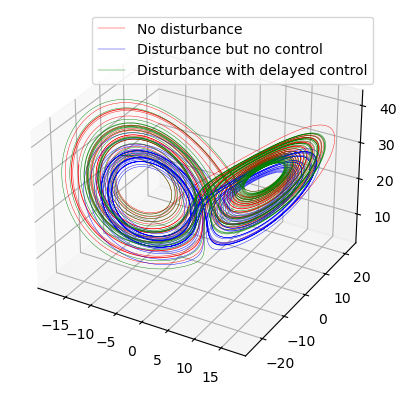

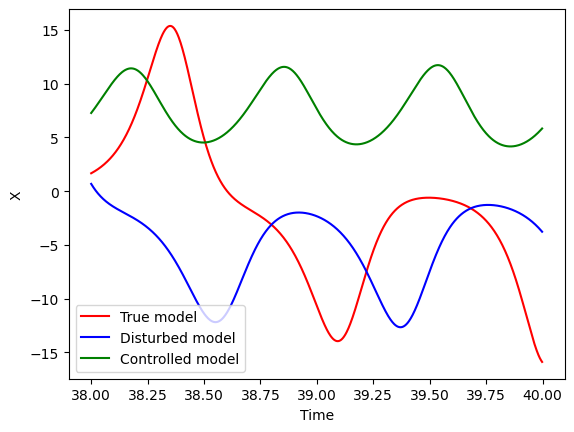

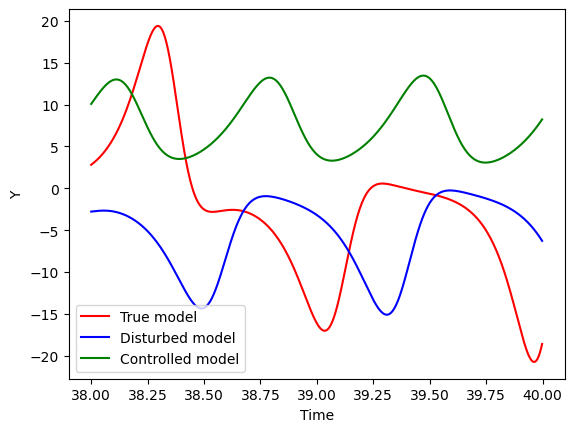

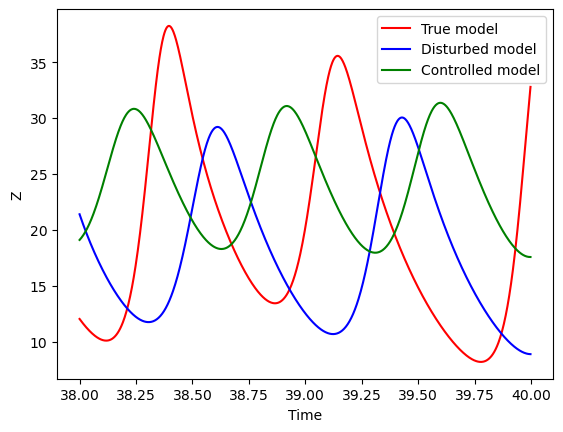

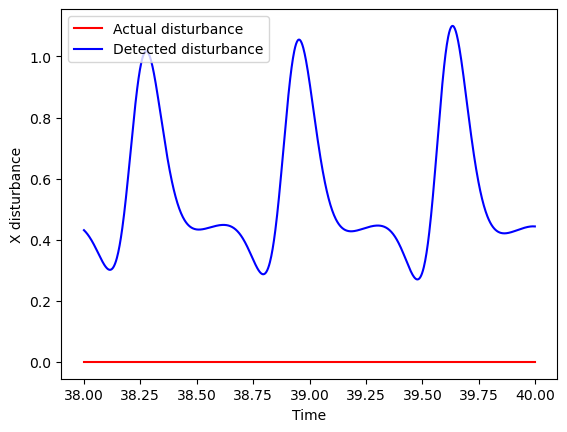

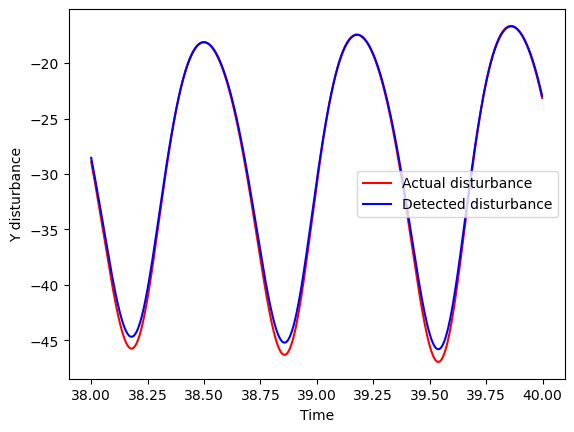

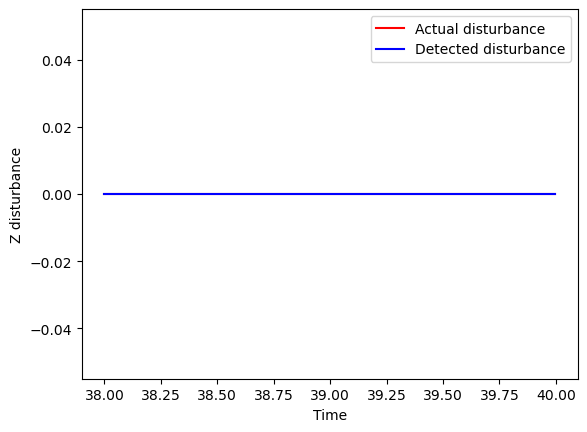

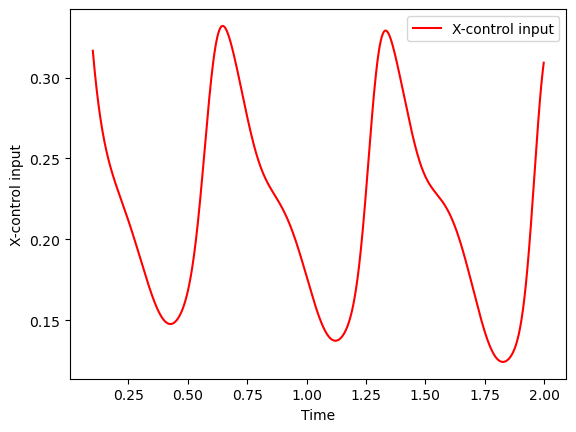

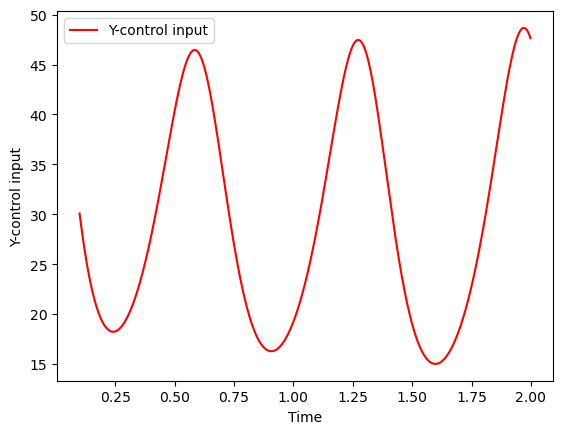

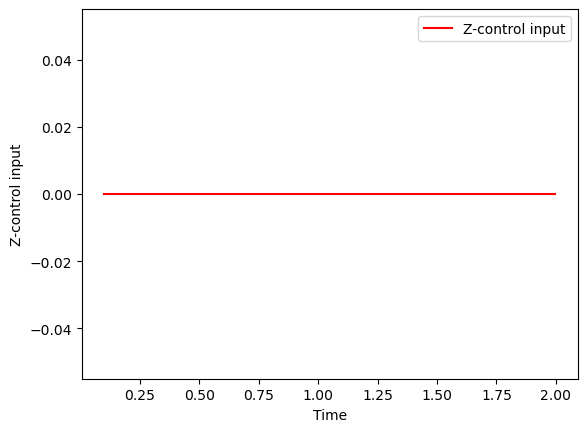

Total energy =  891.4780360459723


In [19]:
## Lorenz system parameters 
sigma = 10
rho = 26
beta = 8/3

## Reservoir parameters
n = 1000                    # reservoir size
m = 3                       # number of dimensions in the system  
mu = 1.2                    # Spectral radius of reservoir adjacency matrix
lam = 0.000001              # Lambda for ridge regression

## Control parameters
alpha = 1000
tau = 10

## Simulation parameters
T = 200
dt = 0.002
ntraining = int(T / dt)
trainingtimes = np.linspace(0, T, ntraining + 1)


## Generate random sparse reservoir adjacency matrix A
A1 = sp.random(n, n, density=6/n, format='csr')    # n x n sparse matrix with values between   
A1 = A1 - 0.5 * np.sign(A1.toarray())              # All non-zero terms are shifted left by 0.5
A1 = A1 * mu / np.abs(sp.linalg.eigs(A1, k=1)[0])  # normalize reservoir matrix 
A = sp.csr_matrix(A1)

## Generate random Win matrix to have entries with values between -0.01 to 0.01
Win = 0.01 * (2.0 * np.random.rand(n, m) - 1)

## Generate random intial state for reservoir with values between -0.5 to 0.5
r = 0.5 - 1.0 * np.random.rand(n)

## Inital state of Lorenz system, reservoir states and forcing function
x, y, z = -7.45, -3.03, 0.01
R = np.zeros((n, ntraining))
f = np.zeros((m, ntraining))


### Training using the pre-defined forcing functions ###

## Collecting reservoir time-series data
for t in range(ntraining):

    u = np.array([x, y, z])
    R[:, t] = r

    fx = 100 * np.cos(0.05 * dt * t)
    fy = 100 * np.sin(0.05 * dt * t)
    
    f[0, t] = fx
    f[1, t] = fy

    xp = sigma * (y - x) + fx
    yp = x * (rho - z) - y + fy
    zp = x * y - beta * z

    x += dt * xp
    y += dt * yp
    z += dt * zp

    r = np.tanh(A.dot(r) + Win.dot(u) + 1)

## Finding Wout matrix using ridge regression
Wout = f.dot(R.T).dot(np.linalg.inv(R.dot(R.T) + lam * np.eye(n)))




### Testing delayed control with altered rho ###

Ttest = 40
ntest = int(Ttest / dt)
testingtimes = np.linspace(0, Ttest, ntest + 1)
disfac = -4

gxnocontrol = np.zeros(ntest)
gxcontrol = np.zeros(ntest)
gpredx = np.zeros(ntest)
ux = np.zeros(ntest + 1)
vx = np.zeros(ntest + 1)

gynocontrol = np.zeros(ntest)
gycontrol = np.zeros(ntest)
gpredy = np.zeros(ntest)
uy = np.zeros(ntest + 1)
vy = np.zeros(ntest + 1)

gznocontrol = np.zeros(ntest)
gzcontrol = np.zeros(ntest)
gpredz = np.zeros(ntest)
uz = np.zeros(ntest + 1)
vz = np.zeros(ntest + 1)

## Storing x, y, z time series data when there is disturbance and control is applied
xcontrol = np.zeros(ntest)             
ycontrol = np.zeros(ntest)
zcontrol = np.zeros(ntest)

## Storing x, y, z time series data when there is disturbance and control is not applied
xnocontrol = np.zeros(ntest)
ynocontrol = np.zeros(ntest)
znocontrol = np.zeros(ntest)

## Storing x, y, z time series data if there was no disturbance
xpure = np.zeros(ntest)
ypure = np.zeros(ntest)
zpure = np.zeros(ntest)


xxcontrol, yycontrol, zzcontrol = x, y, z
xxnocontrol, yynocontrol, zznocontrol = x, y, z
xxpure, yypure, zzpure = x, y, z


temp = Wout.dot(R[:, -1])

for t in range(ntest):

    ## No disturbance and system is evolving with old parameters

    xxpurep = sigma * (yypure - xxpure)
    yypurep = xxpure * (rho - zzpure) - yypure
    zzpurep = xxpure * yypure - beta * zzpure

    xxpure += dt * xxpurep
    yypure += dt * yypurep
    zzpure += dt * zzpurep

    xpure[t] = xxpure
    ypure[t] = yypure
    zpure[t] = zzpure    
    
    

    ## Disturbance but no control
    
    gynocontrol[t] = disfac * xxnocontrol

    # xrossdot = - yross - zross
    # yrossdot = xross + 0.2 * yross
    # zrossdot = 0.2 + zross * (xross - 5.7)

    # xross = xross + dt * xrossdot
    # yross = yross + dt * yrossdot
    # zross = zross + dt * zrossdot

    # gxnocontrol[t] = 50 * xross 
    # gynocontrol[t] = 50 * yross


    xxnocontrolp = sigma * (yynocontrol - xxnocontrol)
    yynocontrolp = xxnocontrol * (rho - zznocontrol) - yynocontrol + gynocontrol[t]
    zznocontrolp = xxnocontrol * yynocontrol - beta * zznocontrol
    
    xxnocontrol += dt * xxnocontrolp
    yynocontrol += dt * yynocontrolp
    zznocontrol += dt * zznocontrolp

    xnocontrol[t] = xxnocontrol
    ynocontrol[t] = yynocontrol
    znocontrol[t] = zznocontrol



    ## Disturbance with delayed control

    gycontrol[t] = disfac * xxcontrol
    
    # gxcontrol[t] = 50 * xross 
    # gycontrol[t] = 50 * yross


    ux[t] = temp[0]
    uy[t] = temp[1]
    uz[t] = temp[2]

    vx[t + 1] = vx[t] + (dt / tau) * (ux[t] - vx[t])
    vy[t + 1] = vy[t] + (dt / tau) * (uy[t] - vy[t])
    vz[t + 1] = vz[t] + (dt / tau) * (uz[t] - vz[t])

    xxcontrolp = sigma * (yycontrol - xxcontrol) + gxcontrol[t] - alpha * vx[t]
    yycontrolp = xxcontrol * (rho - zzcontrol) - yycontrol + gycontrol[t] - alpha * vy[t]
    zzcontrolp = xxcontrol * yycontrol - beta * zzcontrol + gzcontrol[t] - alpha * vz[t]

    xxcontrol += dt * xxcontrolp
    yycontrol += dt * yycontrolp
    zzcontrol += dt * zzcontrolp

    xcontrol[t] = xxcontrol
    ycontrol[t] = yycontrol
    zcontrol[t] = zzcontrol

    temp = np.array([xxcontrol, yycontrol, zzcontrol])
    r = np.tanh(A.dot(r) + Win.dot(temp) + 1)
    temp = Wout.dot(r)
    gpredx[t] = temp[0] + alpha * vx[t]
    gpredy[t] = temp[1] + alpha * vy[t]
    gpredz[t] = temp[2] + alpha * vz[t]




plt.figure()
ax = plt.axes(projection = '3d')
ax.plot3D(xpure, ypure, zpure, 'r', linewidth = 0.3, label = 'No disturbance')
ax.plot3D(xnocontrol, ynocontrol, znocontrol, 'b', linewidth = 0.3, label = 'Disturbance but no control')
ax.plot3D(xcontrol, ycontrol, zcontrol, 'g', linewidth = 0.3, label = 'Disturbance with delayed control')
plt.legend()
plt.show()

# plt.figure()
# ax = plt.axes(projection = '3d')
# ax.plot3D(xpure, ypure, zpure, 'r', linewidth = 0.1, label = 'No disturbance')
# plt.legend()
# plt.show()

# plt.figure()
# ax = plt.axes(projection = '3d')
# ax.plot3D(xnocontrol, ynocontrol, znocontrol, 'b', linewidth = 0.1, label = 'Disturbance but no control')
# plt.legend()
# plt.show()

# plt.figure()
# ax = plt.axes(projection = '3d')
# ax.plot3D(xcontrol, ycontrol, zcontrol, 'g', linewidth = 0.1, label = 'Disturbance with delayed control')
# plt.legend()
# plt.show()

# plt.figure()
# ax = plt.axes(projection = '3d')
# ax.plot3D(xpure, ypure, zpure, 'r', linewidth = 0.1, label = 'No disturbance')
# ax.plot3D(xcontrol, ycontrol, zcontrol, 'g', linewidth = 0.1, label = 'Disturbance with delayed control')
# plt.legend()
# plt.show()

plottimerange = np.arange(ntest - 1000, ntest)

plt.figure()
plt.plot(testingtimes[plottimerange], xpure[plottimerange], 'r', label = 'True model')
plt.plot(testingtimes[plottimerange], xnocontrol[plottimerange],  'b', label = 'Disturbed model')
plt.plot(testingtimes[plottimerange], xcontrol[plottimerange],  'g', label = 'Controlled model')
plt.legend()
plt.xlabel('Time')
plt.ylabel('X')
plt.show()


plt.figure()
plt.plot(testingtimes[plottimerange], ypure[plottimerange], 'r', label = 'True model')
plt.plot(testingtimes[plottimerange], ynocontrol[plottimerange],  'b', label = 'Disturbed model')
plt.plot(testingtimes[plottimerange], ycontrol[plottimerange],  'g', label = 'Controlled model')
plt.legend()
plt.xlabel('Time')
plt.ylabel('Y')
plt.show()

plt.figure()
plt.plot(testingtimes[plottimerange], zpure[plottimerange], 'r', label = 'True model')
plt.plot(testingtimes[plottimerange], znocontrol[plottimerange],  'b', label = 'Disturbed model')
plt.plot(testingtimes[plottimerange], zcontrol[plottimerange],  'g', label = 'Controlled model')
plt.legend()
plt.xlabel('Time')
plt.ylabel('Z')
plt.show()


plt.figure()
plt.plot(testingtimes[plottimerange], gxcontrol[plottimerange], 'r', label = 'Actual disturbance')
plt.plot(testingtimes[plottimerange], gpredx[plottimerange],  'b', label = 'Detected disturbance')
plt.legend()
plt.xlabel('Time')
plt.ylabel('X disturbance')
plt.show()

plt.figure()
plt.plot(testingtimes[plottimerange], gycontrol[plottimerange], 'r', label = 'Actual disturbance')
plt.plot(testingtimes[plottimerange], gpredy[plottimerange],  'b', label = 'Detected disturbance')
plt.legend()
plt.xlabel('Time')
plt.ylabel('Y disturbance')
plt.show()

plt.figure()
plt.plot(testingtimes[plottimerange], gzcontrol[plottimerange], 'r', label = 'Actual disturbance')
plt.plot(testingtimes[plottimerange], gpredz[plottimerange],  'b', label = 'Detected disturbance')
plt.legend()
plt.xlabel('Time')
plt.ylabel('Z disturbance')
plt.show()


plottimerange = np.arange(50, 1000)

# plt.figure()
# plt.plot(testingtimes[plottimerange], xpure[plottimerange], 'r', label = 'Actual disturbance')
# plt.plot(testingtimes[plottimerange], xcontrol[plottimerange],  'b', label = 'Detected disturbance')
# plt.legend()
# plt.xlabel('Time')
# plt.ylabel('X')
# plt.show()


plt.figure()
plt.plot(testingtimes[plottimerange], alpha * vx[plottimerange], 'r', label = 'X-control input')
plt.legend()
plt.xlabel('Time')
plt.ylabel('X-control input')
plt.show()

plt.figure()
plt.plot(testingtimes[plottimerange], alpha * vy[plottimerange], 'r', label = 'Y-control input')
plt.legend()
plt.xlabel('Time')
plt.ylabel('Y-control input')
plt.show()

plt.figure()
plt.plot(testingtimes[plottimerange], alpha * vz[plottimerange], 'r', label = 'Z-control input')
plt.legend()
plt.xlabel('Time')
plt.ylabel('Z-control input')
plt.show()

print("Total energy = ", np.sum(dt * alpha ** 2 * np.sum(vx ** 2 + vy ** 2 + vz ** 2))/Ttest)
